In [4]:
import json
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line))
    return data


In [ ]:
# use this for test data
step1 = load_jsonl('step1_test.jsonl')
step2 = load_jsonl('step2_test.jsonl')
len(step1), len(step2)
batch_size_1 = 8
batch_size_2 = 8

In [85]:
step1_original = load_jsonl('/ssdscratch/byuan48/Reasoning/step1_large_train.jsonl')
step2_original = load_jsonl('/ssdscratch/byuan48/Reasoning/step2_large_train.jsonl')
len(step1_original), len(step2_original)
batch_size_1 = 8
batch_size_2 = 32
step1 = step1_original[:len(step2) // batch_size_2]
step2 = step2_original[:len(step1)*batch_size_2]
len(step1), len(step2)

(2688, 86016)

Step 1 and Step 2 generation are very diverse

In [86]:
number_of_unique_sentences_step1 = []
for i in range(0,len(step1),batch_size_1):
    # print('index:{}',i)
    sentences = []
    for j in range(batch_size_1):
        sentences.append(step1[i+j]['generated_text'])
        # print(step1[i+j]['generated_text'])
        # print('*'  * 50)
    number_of_unique_sentences_step1.append(len(set(sentences)))
# show the percentage of elements in number_of_unique_sentences_step1
for unique_times in set(number_of_unique_sentences_step1):
    print('unique_times:{} percentage:{} in step1'.format(unique_times,number_of_unique_sentences_step1.count(unique_times)/len(number_of_unique_sentences_step1)))
    
    
number_of_unique_sentences_step2 = []
for i in range(0,len(step1),batch_size_2):
    # print('index:{}',i)
    sentences = []
    for j in range(batch_size_2):
        sentences.append(step2[i+j]['generated_text'])
        # print(step2[i+j]['generated_text'])
        # print('*'  * 50)
    number_of_unique_sentences_step2.append(len(set(sentences)))
# show the percentage of elements in number_of_unique_sentences_step1
print("*" * 50)
for unique_times in set(number_of_unique_sentences_step2):
    print('unique_times:{} percentage:{} in step2'.format(unique_times,number_of_unique_sentences_step2.count(unique_times)/len(number_of_unique_sentences_step2)))
        


unique_times:8 percentage:1.0 in step1
**************************************************
unique_times:32 percentage:0.9761904761904762 in step2
unique_times:13 percentage:0.011904761904761904 in step2
unique_times:21 percentage:0.011904761904761904 in step2


Mean similarity between generated texts in step 1
0.79785055


(array([ 1.,  0.,  0.,  0.,  1.,  1.,  0.,  2.,  3.,  0.,  1.,  2.,  0.,
         2.,  4.,  2.,  6.,  1.,  8.,  2.,  3.,  2.,  2.,  9.,  5., 10.,
         9.,  8., 14., 11., 13., 18., 15., 13., 15., 19., 25., 12., 11.,
        16., 10., 13., 10., 14.,  3.,  6.,  6.,  1.,  4.,  3.]),
 array([0.51945299, 0.52797723, 0.53650141, 0.54502559, 0.55354983,
        0.56207407, 0.57059824, 0.57912242, 0.58764666, 0.5961709 ,
        0.60469508, 0.61321926, 0.6217435 , 0.63026774, 0.63879192,
        0.6473161 , 0.65584034, 0.66436458, 0.67288876, 0.68141294,
        0.68993717, 0.69846141, 0.70698559, 0.71550977, 0.72403401,
        0.73255825, 0.74108243, 0.74960661, 0.75813085, 0.76665509,
        0.77517927, 0.78370345, 0.79222769, 0.80075192, 0.8092761 ,
        0.81780028, 0.82632452, 0.83484876, 0.84337294, 0.85189712,
        0.86042136, 0.8689456 , 0.87746978, 0.88599396, 0.8945182 ,
        0.90304244, 0.91156662, 0.92009079, 0.92861503, 0.93713927,
        0.94566345]),
 <BarContainer

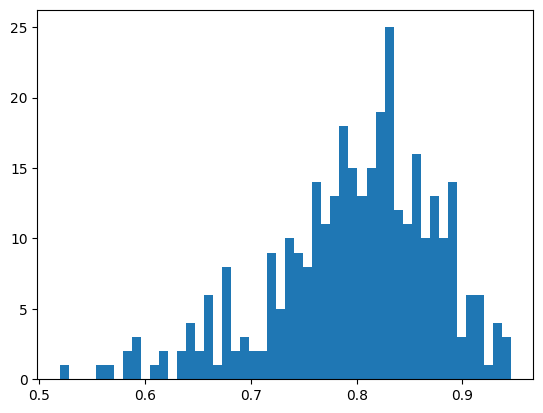

In [90]:
# This is to check the similarity between the generated texts. Currently it indicates that the generated texts are very similar to each other.
# Some hyperparameters
step1_batch_size = batch_size_1
step2_batch_size = batch_size_2
samples = int(len(step1) / step1_batch_size)
# check how similar that each generation in step 1 is
generated_texts = []
for i in range(len(step1)):
    generated_texts.append(step1[i]['generated_text'])

model = SentenceTransformer('all-MiniLM-L6-v2', device='cuda:3') 
similarities = [] 
for i in range(0,len(generated_texts),step1_batch_size):
    embeddings = model.encode(generated_texts[i:i+step1_batch_size])
    similarity_matrix = cosine_similarity(embeddings)
    # print(np.round(similarity_matrix, 2))
    # find the mean of each pair of similarity (not including the diagonal)
    similarities.append(np.mean(similarity_matrix[np.triu_indices(step1_batch_size, k=1)]))
print('Mean similarity between generated texts in step 1')
print(np.mean(similarities))
plt.hist(similarities, bins=50)


embedding based method does not work well

In [91]:
# how do they look like 
index = 3 # the index-th sample starting from 1
print(f"question:{step1[step1_batch_size*(index-1)]['original_prompt']}")
for i in range(step1_batch_size*(index-1), step1_batch_size*index):
    print(generated_texts[i])
    for j in range(step2_batch_size):
        print('*' * 25)
        print(step2[step2_batch_size*i+j]['generated_text'])
        
    print('*' * 50) 
similarities[index-1]

question:You are a helpful assistant for math problem-solving. At the end of the solution, provide the final answer in the format: \boxed{answer}. Now solve the following problem: It took $4$ days for $75$ workers, all working together at the same rate, to build an embankment. If only $50$ workers had been available, how many total days would it have taken to build the embankment?
  
Step 1: Understand the problem and the concept of work rate.
First, we need to understand the relationship between the number of workers and the time needed to complete a task. The work rate is inversely proportional to the time taken. In this case, we have a fixed amount of work (in this case, building an embankment), and we're trying to find how the time changes with different numbers of workers.

Step 2: Use the concept of work rate to set up the equation.
We know that the product of the number of workers and the days to complete the job should be constant if all other conditions are the same. Therefore

0.73806965

In [112]:
import numpy as np
from datasets import load_dataset
# Load the math dataset from Hugging Face
dataset = load_dataset("lighteval/MATH", split="train", trust_remote_code=True)
print(dataset)
print(dataset[0])
# randomly select a subset from the dataset
dataset = dataset.shuffle(seed=42).select(range(samples))

# check noise level in the dataset
import utils
from importlib import reload
reload(utils)
answers, number_invalid_solutions, indices_invalid = utils.extract_boxed_answers([[dataset[i]['solution'] for i in range(len(dataset))]])
print('Number of invalid solutions: ', number_invalid_solutions)
print(f'percentage of invalid solutions: {number_invalid_solutions/len(dataset)}')
indices_invalid = [indices_invalid[i][1] for i in range(len(indices_invalid))]
print('indices_invalid:', indices_invalid)




Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 7500
})
{'problem': 'Let \\[f(x) = \\left\\{\n\\begin{array}{cl} ax+3, &\\text{ if }x>2, \\\\\nx-5 &\\text{ if } -2 \\le x \\le 2, \\\\\n2x-b &\\text{ if } x <-2.\n\\end{array}\n\\right.\\]Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).', 'level': 'Level 5', 'type': 'Algebra', 'solution': 'For the piecewise function to be continuous, the cases must "meet" at $2$ and $-2$. For example, $ax+3$ and $x-5$ must be equal when $x=2$. This implies $a(2)+3=2-5$, which we solve to get $2a=-6 \\Rightarrow a=-3$. Similarly, $x-5$ and $2x-b$ must be equal when $x=-2$. Substituting, we get $-2-5=2(-2)-b$, which implies $b=3$. So $a+b=-3+3=\\boxed{0}$.'}
all_results: [['10', '25 + 2\\sqrt{159}', '6', '36', '33', '\\begin{pmatrix} 1 & 2500 \\\\ 0 & 1 \\end{pmatrix}', '3', '1005', '143', '4', '262', '50', '-75', '2500', '8', '8', '4320'

In [103]:
solutions = [step2[i]['generated_text'] for i in range(len(step2))]
solutions = np.array(solutions).reshape(samples, step1_batch_size, step2_batch_size)
accuracies = np.zeros((samples, step1_batch_size))

# invalid_samples = [31, 424, 449, 450] # for test 
invalid_samples = [167, 190] # for train
indices_invalid = indices_invalid + invalid_samples

for i in range(samples):
    if i in indices_invalid: 
        continue
    print(f'processing the {i+1}-th sample')
    # print('*' * 50)
    print(f'the true solution is {answers[0][i]}')
    for j in range(step1_batch_size):
        # print(f'the {j}-th solution in the {i}-th sample')
        extracted_solutions, _, _ = utils.extract_boxed_answers([solutions[i][j].tolist()])
        _, results_per_answer = utils.check_equivalence(extracted_solutions[0], answers[0][i])
        # check the percentage of correct solutions
        current_accuracy = np.array(results_per_answer).sum()/len(results_per_answer)
        accuracies[i][j] = current_accuracy
        print(f'percentage of correct solutions: {np.array(results_per_answer).sum()/len(results_per_answer)}')
        print('*' * 50)


processing the 1-th sample
the true solution is 10
all_results: [['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10']]
percentage of correct solutions: 1.0
**************************************************
all_results: [['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10']]
percentage of correct solutions: 1.0
**************************************************
all_results: [['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10']]
percentage of correct solutions: 1.0
**************************************************
all_results: [['10', '10', '10', '10', '10', '10', '10', '10'

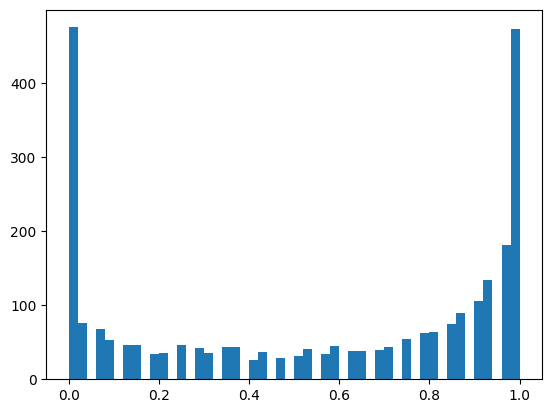

percentage of samples that the difference between the best accuracy and the worst accuracy is larger than 0: 1.0
percentage of samples that the difference between the best accuracy and the worst accuracy is larger than 0.2: 0.6636904761904762
percentage of samples that the difference between the best accuracy and the worst accuracy is larger than 0.4: 0.5208333333333334
percentage of samples that the difference between the best accuracy and the worst accuracy is larger than 0.6: 0.34226190476190477
percentage of samples that the difference between the best accuracy and the worst accuracy is larger than 0.8: 0.23511904761904762
percentage of samples that the difference between the best accuracy and the worst accuracy is larger than 1: 0.0625


In [104]:
# check the distribution of accuracies by histogram
# accuracies = np.delete(accuracies, indices_invalid)
# print(f"existing samples: {len(accuracies)}")
plt.hist(accuracies.flatten(order='C'), bins=50)
plt.show()
# check the percentage of samples that the difference between the best accuracy and the worst accuracy is larger than threshold
for threshold in [0, 0.2, 0.4, 0.6, 0.8, 1]:
    print(f'percentage of samples that the difference between the best accuracy and the worst accuracy is larger than {threshold}: {np.sum(np.max(accuracies, axis=1) - np.min(accuracies, axis=1) >= threshold)/len(accuracies)}')

In [105]:
# save all the data
sentences = [step1[i]['original_prompt'] + step1[i]['generated_text'] for i in range(len(step1))]
accuracies_flatten = accuracies.flatten(order='C')
# save accuracy and sentences in a jsonl file
with open('./generated_datasets/train_whole_dataset.jsonl', 'w') as file:
    for i in range(len(sentences)):
        file.write(json.dumps({'solution': sentences[i], 'accuracy': accuracies_flatten[i]}) + '\n')

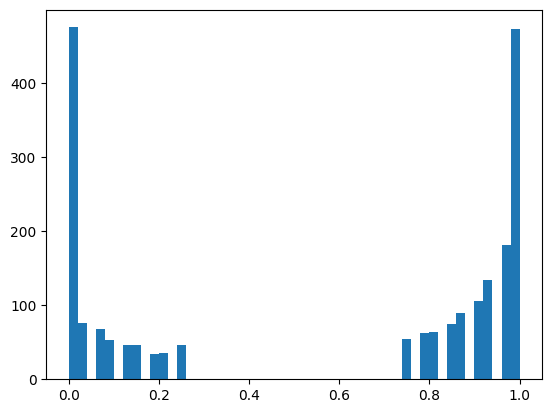

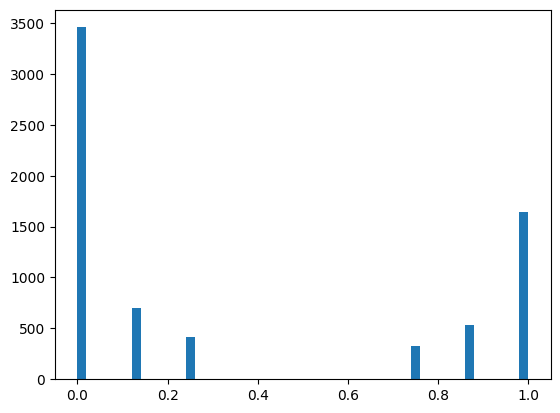

9197


In [6]:
def load_jsonl(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            data.append(json.loads(line))
    return data

trainset = load_jsonl('/ssdscratch/byuan48/Reasoning/generated_datasets/train_whole_dataset.jsonl')
trainset_filtered = [trainset[i] for i in range(len(trainset)) if trainset[i]['accuracy'] >= 0.75 or trainset[i]['accuracy'] <= 0.25]
accuracy_train = [trainset_filtered[i]['accuracy'] for i in range(len(trainset_filtered))]
plt.hist(accuracy_train, bins=50)
plt.show()


testset = load_jsonl('/ssdscratch/byuan48/Reasoning/generated_datasets/test_whole_dataset.jsonl')
testset_filtered = [testset[i] for i in range(len(testset)) if testset[i]['accuracy'] >= 0.75 or testset[i]['accuracy'] <= 0.25]
accuracy_test = [testset_filtered[i]['accuracy'] for i in range(len(testset_filtered))]
with open('./generated_datasets/test_filtered_dataset.jsonl', 'w') as file:
    for i in range(len(testset_filtered)):
        file.write(json.dumps(testset_filtered[i]) + '\n')
plt.hist(accuracy_test, bins=50)
plt.show()

import random
combine_filtered_dataset = trainset_filtered + testset_filtered
random.shuffle(combine_filtered_dataset)
print(len(combine_filtered_dataset))

# with open('./generated_datasets/train_filtered_dataset.jsonl', 'w') as file:
#     for i in range(8500):
#         file.write(json.dumps(combine_filtered_dataset[i]) + '\n')

# with open('./generated_datasets/test_filtered_dataset.jsonl', 'w') as file:
#     for i in range(8500,len(combine_filtered_dataset)):
#         file.write(json.dumps(combine_filtered_dataset[i]) + '\n')

In [ ]:

from datasets import load_dataset
import utils
from importlib import reload
reload(utils)

dataset = load_dataset("lighteval/MATH", split="train", trust_remote_code=True)
dataset = dataset.shuffle(seed=4)

samples = 100
step1_batch_size = 8
step2_batch_size = 16

indices = 20
for index in range(indices):
    
    print(f'processing the {index}-th batch' + '*'*50)
    sub_dataset = dataset.select(range(index*100,(index+1)*100))
    answers, number_invalid_solutions, indices_invalid = utils.extract_boxed_answers([[sub_dataset[t]['solution'] for t in range(len(sub_dataset))]])
    print('Number of invalid solutions: ', number_invalid_solutions)
    print(f'percentage of invalid solutions: {number_invalid_solutions/len(sub_dataset)}')
    indices_invalid = [indices_invalid[t][1] for t in range(len(indices_invalid))]
    print('indices_invalid:', indices_invalid)
    
    step1 = load_jsonl(f"/ssdscratch/byuan48/Reasoning/generated_datasets/step1_large_train_{index}.jsonl")
    step2 = load_jsonl(f"/ssdscratch/byuan48/Reasoning/generated_datasets/step2_large_train_{index}.jsonl")
    solutions = [step2[t]['generated_text'] for t in range(len(step2))]
    solutions = np.array(solutions).reshape(samples, step1_batch_size, step2_batch_size)
    accuracies = np.zeros((samples, step1_batch_size))

    invalid_samples = {0:[33],1:[85],6:[36],9:[14]}
    temp_invalid = invalid_samples[index] if index in invalid_samples.keys() else []
    indices_invalid = indices_invalid + temp_invalid

    for i in range(samples):
        if i in indices_invalid: 
            continue
        print(f'processing the {i}-th sample in the {index}-th batch')
        print(f'the true solution is {answers[0][i]}')
        for j in range(step1_batch_size):
            # print(f'the {j}-th solution in the {i}-th sample')
            extracted_solutions, _, _ = utils.extract_boxed_answers([solutions[i][j].tolist()])
            _, results_per_answer = utils.check_equivalence(extracted_solutions[0], answers[0][i])
            # check the percentage of correct solutions
            current_accuracy = np.array(results_per_answer).sum()/len(results_per_answer)
            accuracies[i][j] = current_accuracy
            print(f'percentage of correct solutions: {np.array(results_per_answer).sum()/len(results_per_answer)}')
            print('-' * 10)



processing the 0-th batch**************************************************
all_results: [['32', '14 \\text{ right triangles}', '24.6', '72', '2^{100} - 2', '1', '\\frac{2}{5}', '3', '5-2\\sqrt3', '\\frac{1}{2}', '689', '59', '20', '28', '\\begin{pmatrix} 16 & -4 \\\\ 37 & -13 \\end{pmatrix}', '67', '\\frac{3 + \\sqrt{5}}{2}', '\\frac{\\pi}{4}', '4', '\\frac{7}{18}', '18', '\\dfrac13', '3027', '\\frac{28}{99}', '5', '250500', '55^\\circ', '6\\sqrt{26}', '120^\\circ', '\\frac72', '72^\\circ', '\\frac{1 + \\sqrt{5}}{2}', '\\sqrt{a^2 + b^2}', '\\frac{3}{7}', '125', '\\sqrt{3}', '334', '\\sqrt{55}', '-\\frac{\\sqrt{3}}{2}', '44', '60\\sqrt{3}', '1', '48', '21', '32', '\\frac{\\pi}{12}', '\\frac{5}{8}', '1,-1,i,-i', '576', '48', '216', '6', '0', '6', '23', '[-1,2]', '\\frac{3}{8}', '(625, \\infty)', '4', '1', '\\frac{9}{7}', '50 \\pi', '0', '75^\\circ', '43', '12378', '15', '2', '5', '10^\\circ', '224', '5 + 45i', '\\frac{\\sqrt{3}}{12}', '3', '\\frac{1}{2}', '\\frac45', '5', '6.4', '36', '

KeyboardInterrupt: 